# Python Project 3: NYPD Arrest Data

---

## Research Question: Do more burglary arrests happen during a certain day of the week?
### Secondary questions:
1. Where do the most burglary arrests occur?
2. Are burglary arrests more common with younger perpatrators?
3. How do burglary arrests rank against robbery arrests?

---




In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('https://raw.githubusercontent.com/melodiebaja/LAGCC-Data-Analytics-Academy/refs/heads/main/NYPD_Arrest_Data_(Year_to_Date)_20260504.csv')

# Understanding the original dataframe
---
##### - Checking the head of data and looking for available arrest descriptions to filter for the analysis.
##### - Checking summary statistics to see data types and possible missing values.
##### - Cleaning up ARREST DATES by converting to datetime datatype.

In [47]:
df.head()

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
0,318451126,01/06/2026,105.0,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,Q,110,0,25-44,M,BLACK,1020232,210719,40.744989,-73.870145,POINT (-73.870145 40.744989)
1,318308486,01/03/2026,203.0,"TRESPASS 3, CRIMINAL",352.0,CRIMINAL TRESPASS,PL 140100G,M,K,77,1,25-44,M,BLACK,1003358,182945,40.668798,-73.931120,POINT (-73.93112014 40.66879784)
2,318550123,01/08/2026,105.0,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,B,48,0,25-44,M,WHITE HISPANIC,1011780,246837,40.844152,-73.900500,POINT (-73.9005 40.844152)
3,318580867,01/07/2026,397.0,"ROBBERY,OPEN AREA UNCLASSIFIED",105.0,ROBBERY,PL 160102B,F,M,28,0,(null),(null),BLACK,999788,233328,40.807102,-73.943874,POINT (-73.943874 40.807102)
4,318684449,01/10/2026,397.0,"ROBBERY,OPEN AREA UNCLASSIFIED",105.0,ROBBERY,PL 160102A,F,B,45,0,<18,F,BLACK,1031351,254245,40.864401,-73.829711,POINT (-73.829711 40.864401)


In [48]:
print('List of offense descriptions categories for analysis:\n')
print(df['OFNS_DESC'].sort_values(ascending=True).unique())

List of offense descriptions categories for analysis:

['(null)' 'ADMINISTRATIVE CODE' 'ADMINISTRATIVE CODES'
 'ALCOHOLIC BEVERAGE CONTROL LAW' 'ANTICIPATORY OFFENSES' 'ARSON'
 'ASSAULT 3 & RELATED OFFENSES' "BURGLAR'S TOOLS" 'BURGLARY'
 'CANNABIS RELATED OFFENSES' 'CHILD ABANDONMENT/NON SUPPORT 1'
 'CRIMINAL MISCHIEF & RELATED OF' 'CRIMINAL TRESPASS' 'DANGEROUS DRUGS'
 'DANGEROUS WEAPONS' 'DISORDERLY CONDUCT' 'DISRUPTION OF A RELIGIOUS SERV'
 'ESCAPE 3' 'FELONY ASSAULT' 'FOR OTHER AUTHORITIES' 'FORGERY' 'FRAUDS'
 'FRAUDULENT ACCOSTING' 'GAMBLING' 'GRAND LARCENY'
 'GRAND LARCENY OF MOTOR VEHICLE' 'HARRASSMENT 2'
 'HOMICIDE-NEGLIGENT,UNCLASSIFIE' 'INTOXICATED & IMPAIRED DRIVING'
 'INTOXICATED/IMPAIRED DRIVING' 'JOSTLING' 'KIDNAPPING & RELATED OFFENSES'
 'MISCELLANEOUS PENAL LAW' 'MOVING INFRACTIONS'
 'MURDER & NON-NEGL. MANSLAUGHTE' 'NEW YORK CITY HEALTH CODE'
 'OFF. AGNST PUB ORD SENSBLTY &' 'OFFENSES AGAINST PUBLIC ADMINI'
 'OFFENSES AGAINST PUBLIC SAFETY' 'OFFENSES AGAINST THE PERSON

In [49]:
print('Summary Statistics:\n')
display(df.describe(include='all'))

Summary Statistics:



,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
count,6.930500e+04,69305,69303.000000,69305,69293.000000,69305,69305,69038,69305,69305.000000,69305.000000,69305,69305,69305,6.930500e+04,69305.000000,69305.000000,69305.000000,69305
unique,NaN,90,NaN,216,NaN,55,778,6,5,NaN,NaN,6,3,7,NaN,NaN,NaN,NaN,18230
top,NaN,03/11/2026,NaN,ASSAULT 3,NaN,ASSAULT 3 & RELATED OFFENSES,PL 1200001,M,K,NaN,NaN,25-44,M,BLACK,NaN,NaN,NaN,NaN,POINT (-73.88151 40.671413)
freq,NaN,1078,NaN,7036,NaN,9415,6881,40761,21111,NaN,NaN,30798,42719,33340,NaN,NaN,NaN,NaN,508
mean,3.204493e+08,NaN,458.246786,NaN,262.637741,NaN,NaN,NaN,NaN,63.387634,0.899690,NaN,NaN,NaN,1.005511e+06,207575.198485,40.736418,-73.922995,NaN
std,1.309817e+06,NaN,279.603446,NaN,149.718811,NaN,NaN,NaN,NaN,34.077372,6.560605,NaN,NaN,NaN,2.229968e+04,29859.100884,0.081820,0.074304,NaN
min,3.182079e+08,NaN,9.000000,NaN,101.000000,NaN,NaN,NaN,NaN,1.000000,0.000000,NaN,NaN,NaN,-7.400000e+01,40.000000,40.505195,-74.253049,NaN
25%,3.193060e+08,NaN,199.000000,NaN,117.000000,NaN,NaN,NaN,NaN,40.000000,0.000000,NaN,NaN,NaN,9.907960e+05,184962.000000,40.674266,-73.976437,NaN
50%,3.204358e+08,NaN,439.000000,NaN,341.000000,NaN,NaN,NaN,NaN,66.000000,0.000000,NaN,NaN,NaN,1.005390e+06,204948.000000,40.729067,-73.923689,NaN
75%,3.215846e+08,NaN,744.000000,NaN,344.000000,NaN,NaN,NaN,NaN,90.000000,0.000000,NaN,NaN,NaN,1.017119e+06,236070.000000,40.814611,-73.881510,NaN


In [50]:
most_common_arrests = df['OFNS_DESC'].value_counts().reset_index()
most_common_arrests.columns = ['OFNS_DESC', 'Count']
print('Top 10 Most Common Arrests:')
display(most_common_arrests.head(16))

Top 10 Most Common Arrests:


,OFNS_DESC,Count
0,ASSAULT 3 & RELATED OFFENSES,9415
1,PETIT LARCENY,6478
2,DANGEROUS DRUGS,5726
3,FELONY ASSAULT,5462
4,VEHICLE AND TRAFFIC LAWS,4776
5,MISCELLANEOUS PENAL LAW,4627
6,OTHER OFFENSES RELATED TO THEFT,4019
7,CRIMINAL MISCHIEF & RELATED OF,2929
8,OFFENSES AGAINST PUBLIC ADMINI,2679
9,ROBBERY,2593


Secondary Research Question 3 Conclusion: Burglary arrests (#13) are ranked below Robbery arrests (#9), so robbery arrests are more common.

In [51]:
print('Missing Values:')
display(df.isnull().sum())

Missing Values:


,0
ARREST_KEY,0
ARREST_DATE,0
PD_CD,2
PD_DESC,0
KY_CD,12
OFNS_DESC,0
LAW_CODE,0
LAW_CAT_CD,267
ARREST_BORO,0
ARREST_PRECINCT,0


In [52]:
df['ARREST_DATE'] = pd.to_datetime(df['ARREST_DATE'], errors='coerce')
print("Data types after converting 'ARREST_DATE':")
display(df.dtypes)

Data types after converting 'ARREST_DATE':


,0
ARREST_KEY,int64
ARREST_DATE,datetime64[ns]
PD_CD,float64
PD_DESC,object
KY_CD,float64
OFNS_DESC,object
LAW_CODE,object
LAW_CAT_CD,object
ARREST_BORO,object
ARREST_PRECINCT,int64


# Filtering for research question analysis
---
##### - Create new dataframe of burglary information for analysis
##### - Group by day of the week to understand trend throughout the week and confirm which days may have more burglary arrests
##### - Filter data and create visuals to answer research questions

In [53]:
burglary_df = df[df['OFNS_DESC'] == 'BURGLARY'].copy()
print("Filtered DataFrame for 'BURGLARY' offenses:")
display(burglary_df.head())

Filtered DataFrame for 'BURGLARY' offenses:


,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
23,321157325,2026-03-02,223.0,"BURGLARY,RESIDENCE,NIGHT",107.0,BURGLARY,PL 1402502,F,B,50,0,45-64,M,WHITE,1010983,261033,40.883120,-73.903322,POINT (-73.903322 40.88312)
26,321592435,2026-03-10,244.0,"BURGLARY,UNCLASSIFIED,UNKNOWN",107.0,BURGLARY,PL 1402000,F,M,19,0,45-64,M,BLACK,994296,218679,40.766905,-73.963731,POINT (-73.963731 40.766905)
74,319309850,2026-01-22,244.0,"BURGLARY,UNCLASSIFIED,UNKNOWN",107.0,BURGLARY,PL 1402000,F,M,13,0,25-44,M,BLACK,988971,207813,40.737082,-73.982963,POINT (-73.982963 40.737082)
76,318645763,2026-01-09,244.0,"BURGLARY,UNCLASSIFIED,UNKNOWN",107.0,BURGLARY,PL 1402501,F,B,40,2,25-44,F,BLACK,1006063,238341,40.820848,-73.921188,POINT (-73.921188 40.820848)
213,318320552,2026-01-03,244.0,"BURGLARY,UNCLASSIFIED,UNKNOWN",107.0,BURGLARY,PL 1402000,F,M,13,0,25-44,M,BLACK,988971,207813,40.737082,-73.982963,POINT (-73.982963 40.737082)


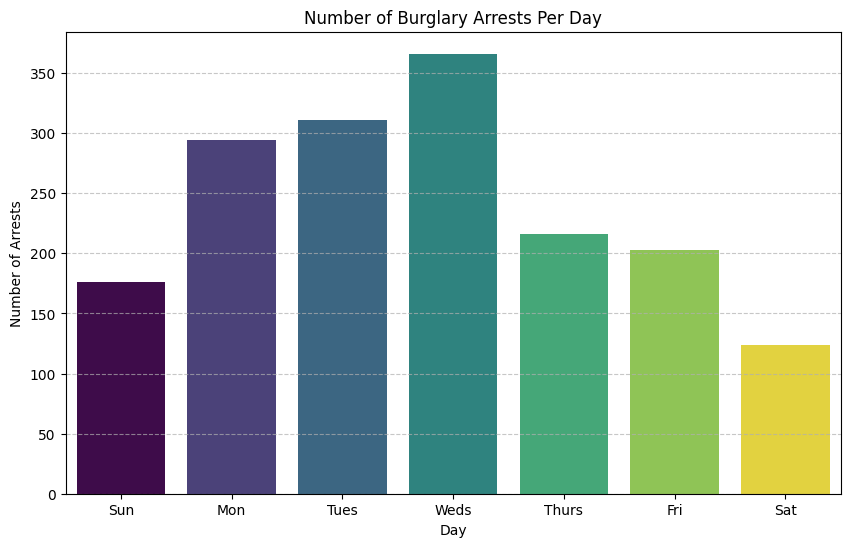

In [66]:
burglary_df['ARREST_DAY'] = burglary_df['ARREST_DATE'].dt.day_of_week
daily_burglary_arrests = burglary_df['ARREST_DAY'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=daily_burglary_arrests.index, y=daily_burglary_arrests.values, palette='viridis', hue=daily_burglary_arrests.index, legend=False)
plt.title('Number of Burglary Arrests Per Day')
plt.xlabel('Day')
plt.ylabel('Number of Arrests')
plt.xticks(ticks=range(0, 7), labels=['Sun', 'Mon', 'Tues', 'Weds', 'Thurs', 'Fri', 'Sat'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Research Question Conclusion: Most burglary arrests have occurred on a Wednesday

In [55]:
robbery_df = df[df['OFNS_DESC'] == 'ROBBERY'].copy()
print("Filtered DataFrame for 'ROBBERY' offenses:")
display(robbery_df.head())

Filtered DataFrame for 'ROBBERY' offenses:


,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
3,318580867,2026-01-07,397.0,"ROBBERY,OPEN AREA UNCLASSIFIED",105.0,ROBBERY,PL 160102B,F,M,28,0,(null),(null),BLACK,999788,233328,40.807102,-73.943874,POINT (-73.943874 40.807102)
4,318684449,2026-01-10,397.0,"ROBBERY,OPEN AREA UNCLASSIFIED",105.0,ROBBERY,PL 160102A,F,B,45,0,<18,F,BLACK,1031351,254245,40.864401,-73.829711,POINT (-73.829711 40.864401)
9,319730888,2026-02-01,397.0,"ROBBERY,OPEN AREA UNCLASSIFIED",105.0,ROBBERY,PL 1600500,F,Q,103,0,25-44,M,BLACK,1038009,194117,40.699330,-73.806123,POINT (-73.806123 40.69933)
10,319499488,2026-01-27,397.0,"ROBBERY,OPEN AREA UNCLASSIFIED",105.0,ROBBERY,PL 160102A,F,K,94,0,25-44,M,BLACK,997245,204129,40.726964,-73.953116,POINT (-73.953116 40.726964)
70,318830484,2026-01-13,397.0,"ROBBERY,OPEN AREA UNCLASSIFIED",105.0,ROBBERY,PL 1600500,F,Q,104,0,18-24,M,BLACK,1012640,203329,40.724732,-73.897573,POINT (-73.897573 40.724732)


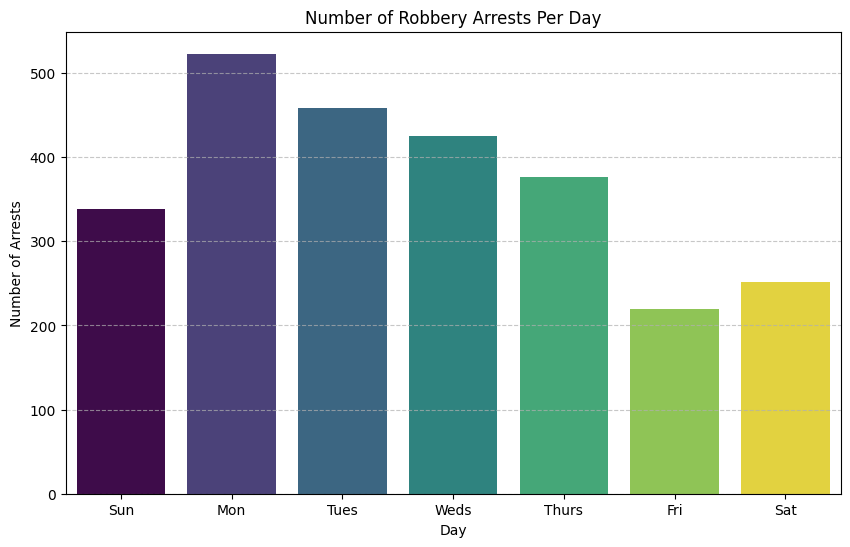

In [67]:
robbery_df['ARREST_DAY'] = robbery_df['ARREST_DATE'].dt.day_of_week
daily_robbery_arrests = robbery_df['ARREST_DAY'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=daily_robbery_arrests.index, y=daily_robbery_arrests.values, palette='viridis', hue=daily_robbery_arrests.index, legend=False)
plt.title('Number of Robbery Arrests Per Day')
plt.xlabel('Day')
plt.ylabel('Number of Arrests')
plt.xticks(ticks=range(0, 7), labels=['Sun', 'Mon', 'Tues', 'Weds', 'Thurs', 'Fri', 'Sat'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Follow-up Conclusion: Robbery arrests appear to occur more frequently on Mondays and decline as the week progresses.




In [57]:
!pip install folium

In [58]:
import folium

# Filter out rows with missing latitude or longitude for mapping
burglary_map_df = burglary_df.dropna(subset=['Latitude', 'Longitude']).copy()

# Get the mean latitude and longitude to center the map
map_center = [burglary_map_df['Latitude'].mean(), burglary_map_df['Longitude'].mean()]

# Create a Folium map object
burglary_map = folium.Map(location=map_center, zoom_start=12)

# Add markers for each burglary arrest
for idx, row in burglary_map_df.iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=f"Arrest Key: {row['ARREST_KEY']}<br>Description: {row['OFNS_DESC']}<br>Date: {row['ARREST_DATE'].strftime('%Y-%m-%d')}",
        tooltip=row['OFNS_DESC']
    ).add_to(burglary_map)

# Display the map
display(burglary_map)

In [68]:
burglary_by_borough = burglary_df['ARREST_BORO'].value_counts()
print('Burglary Arrests by Borough:')
display(burglary_by_borough)

Burglary Arrests by Borough:


,count
ARREST_BORO,
M,602
K,474
B,336
Q,253
S,25


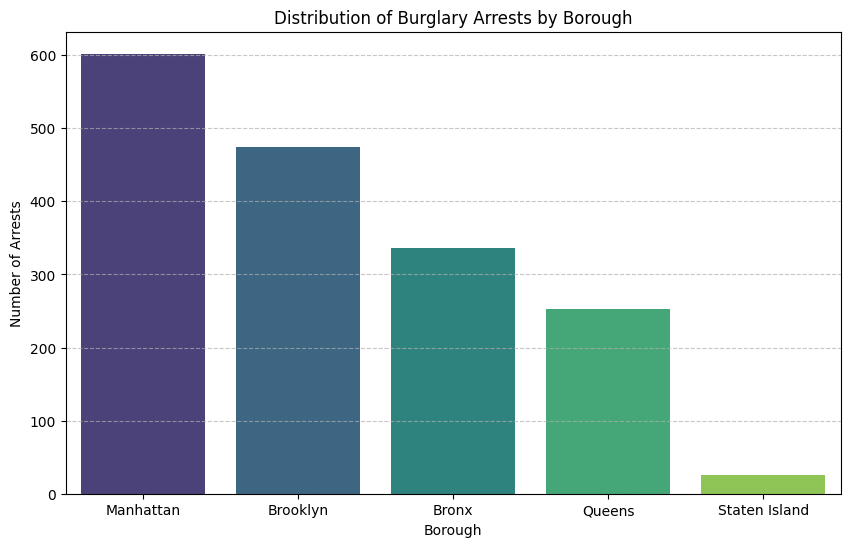

In [72]:
plt.figure(figsize=(10, 6))
sns.barplot(x=burglary_by_borough.index, y=burglary_by_borough.values, palette='viridis', hue=burglary_by_borough.index, legend=False)
plt.title('Distribution of Burglary Arrests by Borough')
plt.xlabel('Borough')
plt.xticks(ticks=range(0, 5), labels=['Manhattan', 'Brooklyn', 'Bronx', 'Queens', 'Staten Island'])
plt.ylabel('Number of Arrests')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Research Question Conclusion: The most burglary arrests occur in Manhattan

In [59]:
print('Age Group Distribution for Burglary Arrests:')
display(burglary_df['AGE_GROUP'].value_counts())

Age Group Distribution for Burglary Arrests:


,count
AGE_GROUP,
25-44,852
45-64,431
(null),218
18-24,136
65+,29
<18,24


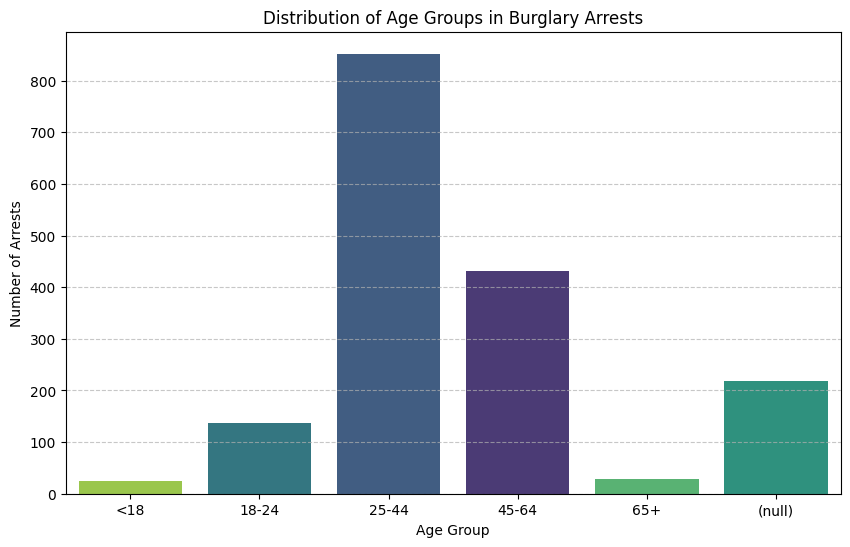

In [64]:
plt.figure(figsize=(10, 6))
age_order = ['<18', '18-24', '25-44', '45-64', '65+', '(null)']
sns.countplot(data=burglary_df, x='AGE_GROUP', order=age_order, palette='viridis', hue='AGE_GROUP', legend=False)
plt.title('Distribution of Age Groups in Burglary Arrests')
plt.xlabel('Age Group')
plt.ylabel('Number of Arrests')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Research Question Conclusion: Burglary arrests are most common among perpetrators aged 25-44, indicating that they are **not** more common with younger perpetrators.

# Conclusions
---
Most burglary arrests have occurred on a Wednesday.
- Follow-up comparision: Robbery arrests appear to occur more frequently on Mondays and decline as the week progresses.
---

Secondary Questions:
1. The most burglary arrests occur in Manhattan, and least frequently in Staten Island.
2. Burglary arrests are most common among perpetrators aged 25-44, indicating that they are not more common with younger perpetrators.
3. Burglary arrests (#13) are ranked below Robbery arrests (#9), so robbery arrests are more common.